In [ ]:
!pip -q install timm

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

Device : cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/research_data/final_dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

/content/drive/MyDrive/research_data/final_dataset/train
/content/drive/MyDrive/research_data/final_dataset/val
/content/drive/MyDrive/research_data/final_dataset/test


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/research_data"))

['FaceForensics++_C23', 'extracted_frames', 'final_dataset', 'efficientnet_best.pth', 'efficientnet_results.csv', 'best_convnext.pth', 'convnext_results.csv', 'val.csv', 'train.csv', 'test.csv', 'best_vit.pth', 'best_vit_timm.pth', 'best_swin.pth', 'checkpoint_swin.pth', 'best_deit_small.pth', 'checkpoint_deit_small.pth']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/research_data/final_dataset"))

['real', 'fake']


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/research_data/train.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/research_data/val.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/research_data/test.csv")

print(len(train_df))
print(len(val_df))
print(len(test_df))

train_df.head()

8470
1815
1815


,image_path,label
0,/content/drive/MyDrive/research_data/final_dat...,fake
1,/content/drive/MyDrive/research_data/final_dat...,fake
2,/content/drive/MyDrive/research_data/final_dat...,fake
3,/content/drive/MyDrive/research_data/final_dat...,fake
4,/content/drive/MyDrive/research_data/final_dat...,real


In [ ]:
print(train_df.columns)

Index(['image_path', 'label'], dtype='object')


In [ ]:
from PIL import Image
import torch
from torch.utils.data import Dataset

class BrainDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        if label == "real":
            label = 1
        else:
            label = 0

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

print("BrainDataset Ready")

BrainDataset Ready


In [ ]:
from torchvision import transforms

IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms Ready")

Transforms Ready


In [ ]:
train_dataset = BrainDataset(train_df, train_transform)
val_dataset   = BrainDataset(val_df, test_transform)
test_dataset  = BrainDataset(test_df, test_transform)

print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(val_dataset))
print("Test Dataset :", len(test_dataset))

Train Dataset : 8470
Validation Dataset : 1815
Test Dataset : 1815


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 265
Validation batches : 57
Test batches : 57


In [ ]:
from torchvision import models
import torch.nn as nn

In [ ]:
# ConvNeXt (Torchvision)
convnext = models.convnext_tiny(
    weights=None
)

convnext.classifier[2] = nn.Linear(
    convnext.classifier[2].in_features,
    2
)

convnext.load_state_dict(
    torch.load(
        BASE_PATH + "/best_convnext.pth",
        map_location=device
    )
)

convnext.to(device)
convnext.eval()

print("✅ ConvNeXt Loaded Successfully")

✅ ConvNeXt Loaded Successfully


In [ ]:
from transformers import AutoModelForImageClassification
import timm

NUM_CLASSES = 2

# EfficientNet (Hugging Face)
efficientnet = AutoModelForImageClassification.from_pretrained(
    "google/efficientnet-b0",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

# ViT
vit = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=NUM_CLASSES
)

# DeiT
deit = timm.create_model(
    "deit_small_patch16_224",
    pretrained=False,
    num_classes=NUM_CLASSES
)

# Swin Transformer
swin = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=NUM_CLASSES
)

print("Models Created Successfully")

config.json:   0%|          | 0.00/70.3k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

[transformers] EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b0
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1280]) vs model:torch.Size([2, 1280])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Models Created Successfully


In [ ]:
import torch

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [ ]:
# import os

# print(os.listdir("/content/drive/MyDrive")[:20])

In [ ]:
# import os

# print(os.listdir("/content/drive/MyDrive/research_data"))

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/research_data/efficientnet_best.pth"))

True


In [ ]:
# import torch

# ckpt = torch.load(
#     "/content/drive/MyDrive/research_data/efficientnet_best.pth",
#     map_location="cpu"
# )

# print(type(ckpt))

# if isinstance(ckpt, dict):
#     print(ckpt.keys())

In [ ]:
# model_keys = list(efficientnet.state_dict().keys())
# ckpt_keys = list(torch.load(
#     "/content/drive/MyDrive/research_data/efficientnet_best.pth",
#     map_location="cpu"
# ).keys())

# print("Model first 20 keys:")
# print(model_keys[:20])

# print("\nCheckpoint first 20 keys:")
# print(ckpt_keys[:20])

In [ ]:
# import transformers
# print(transformers.__version__)

In [ ]:
# BASE_PATH = "/content/drive/MyDrive/research_data"

# state_dict = torch.load(
#     BASE_PATH + "/efficientnet_best.pth",
#     map_location=device
# )

# efficientnet.load_state_dict(state_dict)

# efficientnet.to(device)
# efficientnet.eval()

# print("✅ EfficientNet Loaded Successfully")

In [ ]:
import torch

BASE_PATH = "/content/drive/MyDrive/research_data"

state_dict = torch.load(
    BASE_PATH + "/efficientnet_best.pth",
    map_location=device
)

efficientnet.load_state_dict(state_dict)

efficientnet.to(device)
efficientnet.eval()

print("✅ EfficientNet Loaded Successfully")

✅ EfficientNet Loaded Successfully


In [ ]:
!ls /content/drive/MyDrive/research_data

best_convnext.pth	   checkpoint_swin.pth	     final_dataset
best_deit_small.pth	   convnext_results.csv      test.csv
best_swin.pth		   efficientnet_best.pth     train.csv
best_vit.pth		   efficientnet_results.csv  val.csv
best_vit_timm.pth	   extracted_frames
checkpoint_deit_small.pth  FaceForensics++_C23


In [ ]:
# ConvNeXt
convnext.load_state_dict(
    torch.load(BASE_PATH + "/best_convnext.pth", map_location=device)
)

# ViT
vit.load_state_dict(
    torch.load(BASE_PATH + "/best_vit_timm.pth", map_location=device)
)

# Swin
swin.load_state_dict(
    torch.load(BASE_PATH + "/best_swin.pth", map_location=device)
)

# DeiT
deit.load_state_dict(
    torch.load(BASE_PATH + "/best_deit_small.pth", map_location=device)
)

convnext.to(device).eval()
vit.to(device).eval()
swin.to(device).eval()
deit.to(device).eval()

print("✅ All models loaded successfully!")

✅ All models loaded successfully!


In [ ]:
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

all_labels = []
all_preds = []
all_probs = []

efficientnet.eval()
convnext.eval()
vit.eval()
swin.eval()
deit.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # EfficientNet (HuggingFace)
        out1 = efficientnet(images).logits
        prob1 = torch.softmax(out1, dim=1)

        # ConvNeXt
        out2 = convnext(images)
        prob2 = torch.softmax(out2, dim=1)

        # ViT
        out3 = vit(images)
        prob3 = torch.softmax(out3, dim=1)

        # Swin
        out4 = swin(images)
        prob4 = torch.softmax(out4, dim=1)

        # DeiT
        out5 = deit(images)
        prob5 = torch.softmax(out5, dim=1)

        # Soft Voting
        avg_prob = (prob1 + prob2 + prob3 + prob4 + prob5) / 5

        preds = torch.argmax(avg_prob, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(avg_prob[:,1].cpu().numpy())

In [ ]:
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("="*60)
print("ENSEMBLE RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc:.4f}")

print("\nClassification Report\n")
print(classification_report(all_labels, all_preds))

ENSEMBLE RESULTS
Accuracy  : 0.9218
Precision : 0.9984
Recall    : 0.8120
F1 Score  : 0.8956
AUC Score : 0.9195

Classification Report

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1065
           1       1.00      0.81      0.90       750

    accuracy                           0.92      1815
   macro avg       0.94      0.91      0.92      1815
weighted avg       0.93      0.92      0.92      1815



<Figure size 600x600 with 0 Axes>

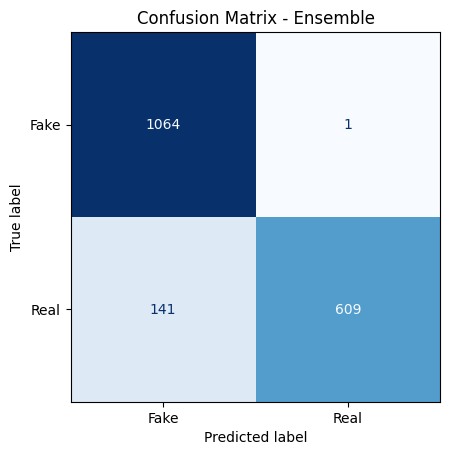

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake","Real"]
)

disp.plot(cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - Ensemble")
plt.show()

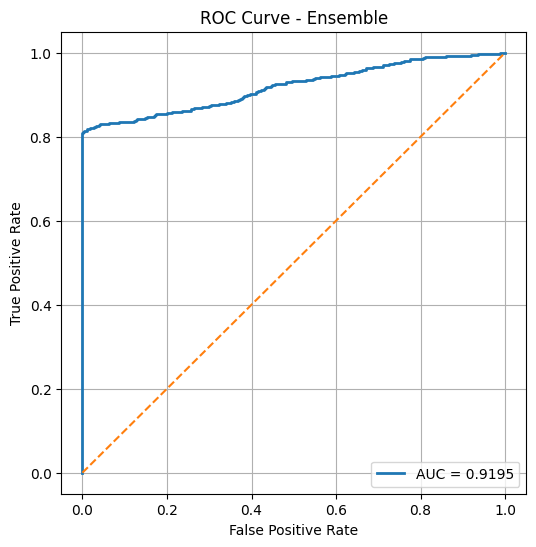

Ensemble Evaluation Completed!


In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, linewidth=2,
         label=f"AUC = {auc:.4f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Ensemble")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("="*60)
print("Ensemble Evaluation Completed!")
print("="*60)